In [27]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

In [28]:
df = pd.read_csv("superstore.csv")
df.head()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-06-09,Monitor,Technology,South,3,222.55,26.43
1,2025-02-16,Monitor,Technology,North,10,3415.83,932.67
2,2024-02-21,Tablet,Technology,South,9,255.74,18.78
3,2025-12-21,Headphone,Technology,West,4,230.03,22.94
4,2025-08-13,Phone,Technology,North,3,2987.40,753.89


In [29]:
print("Rows :",df.shape[0])
print("Columns :",df.shape[1])

Rows : 5000
Columns : 7


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    5000 non-null   object 
 1   Product Name  5000 non-null   object 
 2   Category      5000 non-null   object 
 3   Region        5000 non-null   object 
 4   Quantity      5000 non-null   int64  
 5   Sales         5000 non-null   float64
 6   Profit        5000 non-null   float64
dtypes: float64(2), int64(1), object(4)
memory usage: 273.6+ KB


In [31]:
df.isnull().sum()

Order Date      0
Product Name    0
Category        0
Region          0
Quantity        0
Sales           0
Profit          0
dtype: int64

In [32]:
df.describe()

,Quantity,Sales,Profit
count,5000.000000,5000.000000,5000.000000
mean,5.492400,2562.384470,447.132768
std,2.911982,1411.637954,327.499370
min,1.000000,100.450000,6.920000
25%,3.000000,1373.952500,183.900000
50%,5.000000,2561.455000,371.960000
75%,8.000000,3805.040000,654.807500
max,10.000000,4998.560000,1463.520000


In [33]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"]
)

In [34]:
df["Year"] = df["Order Date"].dt.year

df["Month"] = df["Order Date"].dt.month

df["Day"] = df["Order Date"].dt.day

df["Quarter"] = df["Order Date"].dt.quarter

df["Weekday"] = df["Order Date"].dt.day_name()

In [35]:
df.head()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit,Year,Month,Day,Quarter,Weekday
0,2024-06-09,Monitor,Technology,South,3,222.55,26.43,2024,6,9,2,Sunday
1,2025-02-16,Monitor,Technology,North,10,3415.83,932.67,2025,2,16,1,Sunday
2,2024-02-21,Tablet,Technology,South,9,255.74,18.78,2024,2,21,1,Wednesday
3,2025-12-21,Headphone,Technology,West,4,230.03,22.94,2025,12,21,4,Sunday
4,2025-08-13,Phone,Technology,North,3,2987.40,753.89,2025,8,13,3,Wednesday


In [36]:
total_sales = df["Sales"].sum()

print(
    "Total Revenue : ₹",
    round(total_sales,2)
)

Total Revenue : ₹ 12811922.35


In [37]:
total_profit = df["Profit"].sum()

print(
    "Total Profit : ₹",
    round(total_profit,2)
)

Total Profit : ₹ 2235663.84


In [38]:
print(
    "Total Orders :",
    len(df)
)

Total Orders : 5000


In [39]:
print(
    "Average Sales :",
    round(df["Sales"].mean(),2)
)

Average Sales : 2562.38


In [40]:
monthly_sales = (
    df.groupby("Month")
    ["Sales"]
    .sum()
    .reset_index()
)

monthly_sales

,Month,Sales
0,1,1054268.59
1,2,1006965.60
2,3,1092311.76
3,4,1090892.18
4,5,1041310.29
5,6,1080433.39
6,7,1113421.47
7,8,1124631.02
8,9,993783.38
9,10,1100029.58


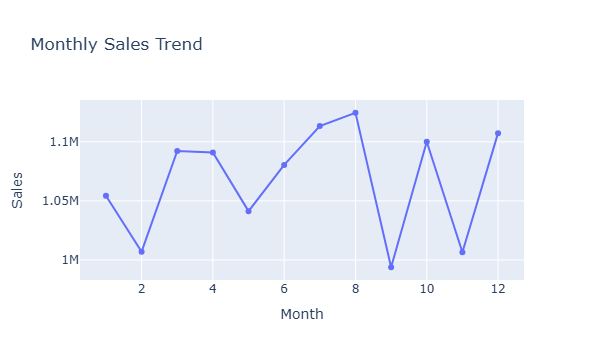

In [41]:
fig = px.line(
    monthly_sales,
    x="Month",
    y="Sales",
    markers=True,
    title="Monthly Sales Trend"
)

fig.show()

In [42]:
region_sales = (
    df.groupby("Region")
    ["Sales"]
    .sum()
    .reset_index()
)

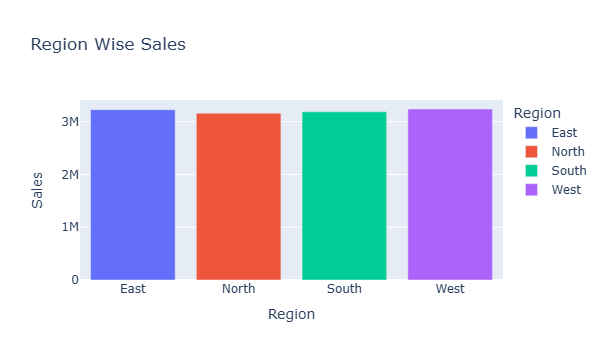

In [44]:
fig = px.bar(
    region_sales,
    x="Region",
    y="Sales",
    color="Region",
    title="Region Wise Sales"
)

fig.show()

In [45]:
category_sales = (
    df.groupby("Category")
    ["Sales"]
    .sum()
    .reset_index()
)

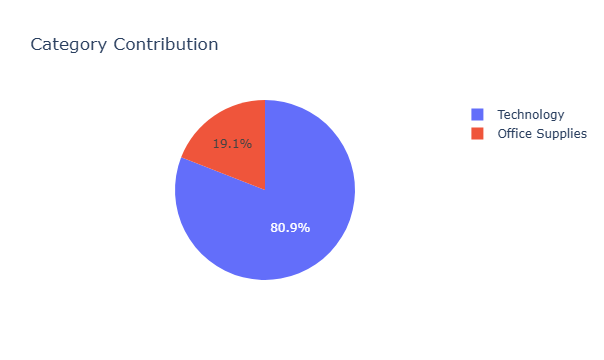

In [46]:
fig = px.pie(
    category_sales,
    names="Category",
    values="Sales",
    title="Category Contribution"
)

fig.show()

In [47]:
top_products = (
    df.groupby("Product Name")
    ["Sales"]
    .sum()
    .sort_values(
        ascending=False
    )
    .head(10)
)

top_products

Product Name
Tablet       1420382.46
Headphone    1395596.70
Speaker      1356326.45
Phone        1283710.63
Scanner      1273296.65
Monitor      1250441.95
Keyboard     1229425.66
Mouse        1221059.85
Laptop       1209174.57
Printer      1172507.43
Name: Sales, dtype: float64

In [48]:
X = df[[
    "Year",
    "Month",
    "Day",
    "Quarter",
    "Quantity"
]]

In [49]:
y = df["Sales"]

In [50]:
X.head()

,Year,Month,Day,Quarter,Quantity
0,2024,6,9,2,3
1,2025,2,16,1,10
2,2024,2,21,1,9
3,2025,12,21,4,4
4,2025,8,13,3,3


In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(4000, 5)
(1000, 5)


In [52]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [53]:
y_pred = model.predict(X_test)

y_pred[:10]

array([1869.58439173, 2670.36747629, 2802.15198379, 2232.60838246,
       2473.42794406, 2738.13407221, 2715.69078401, 2777.6901503 ,
       2497.2667373 , 1981.94995893])

In [54]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test,y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test,y_pred)
)

r2 = r2_score(y_test,y_pred)

print("MAE :",mae)
print("RMSE :",rmse)
print("R2 :",r2)

MAE : 1271.0220603787789
RMSE : 1474.0306031249045
R2 : -0.04243879724430566


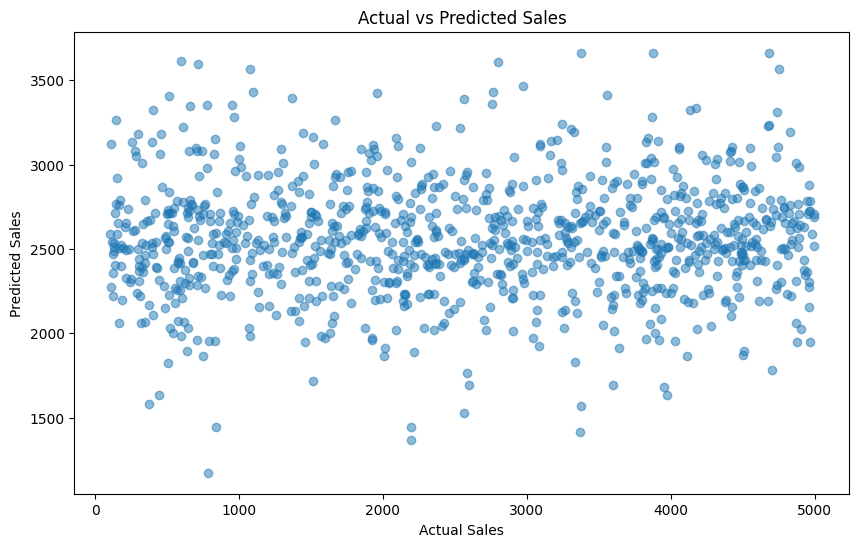

In [55]:
plt.figure(figsize=(10,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title(
    "Actual vs Predicted Sales"
)

plt.show()

In [56]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False,
    inplace=True
)

importance

,Feature,Importance
2,Day,0.355664
4,Quantity,0.258354
1,Month,0.218233
0,Year,0.130760
3,Quarter,0.036989


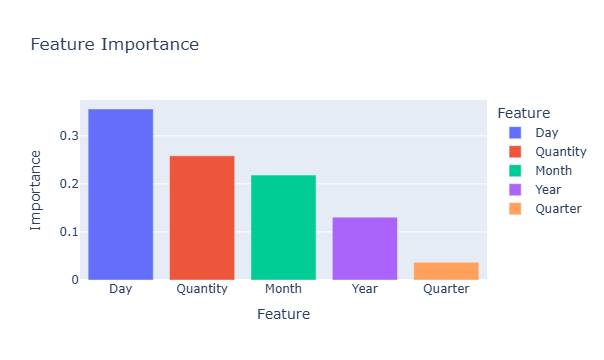

In [57]:
fig = px.bar(
    importance,
    x="Feature",
    y="Importance",
    color="Feature",
    title="Feature Importance"
)

fig.show()

In [58]:
future = pd.DataFrame({

    "Year":[2026],

    "Month":[8],

    "Day":[1],

    "Quarter":[3],

    "Quantity":[5]

})

In [59]:
future_sales = model.predict(
    future
)

print(
    "Predicted Future Sales : ₹",
    round(future_sales[0],2)
)

Predicted Future Sales : ₹ 2618.29


In [60]:
print("="*40)

print(
    "PREDICTIVE SALES FORECAST"
)

print("="*40)

print(
    "Predicted Sales : ₹",
    round(future_sales[0],2)
)

print("="*40)

PREDICTIVE SALES FORECAST
Predicted Sales : ₹ 2618.29


In [61]:
best_region = (
    df.groupby("Region")
    ["Sales"]
    .sum()
    .idxmax()
)

best_product = (
    df.groupby("Product Name")
    ["Sales"]
    .sum()
    .idxmax()
)

print(
    f"Best Region : {best_region}"
)

print(
    f"Top Product : {best_product}"
)

print(
    "Recommendation : Focus inventory on top products and expand marketing in best performing region."
)

Best Region : West
Top Product : Tablet
Recommendation : Focus inventory on top products and expand marketing in best performing region.


In [62]:
daily_sales = (
    df.groupby("Order Date")["Sales"]
    .sum()
    .reset_index()
)

daily_sales.head()

,Order Date,Sales
0,2023-06-08,17756.26
1,2023-06-09,18277.12
2,2023-06-10,17457.24
3,2023-06-11,18902.97
4,2023-06-12,542.15


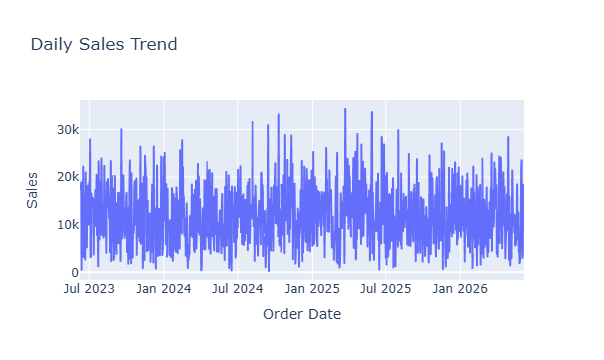

In [63]:
fig = px.line(
    daily_sales,
    x="Order Date",
    y="Sales",
    title="Daily Sales Trend"
)

fig.show()

In [64]:
daily_sales["Moving_Avg"] = (
    daily_sales["Sales"]
    .rolling(window=7)
    .mean()
)

In [65]:
daily_sales.tail()

,Order Date,Sales,Moving_Avg
1081,2026-06-03,3011.16,10772.022857
1082,2026-06-04,3690.53,10951.872857
1083,2026-06-05,17507.76,12586.274286
1084,2026-06-06,18373.35,13663.465714
1085,2026-06-07,18163.09,13136.947143


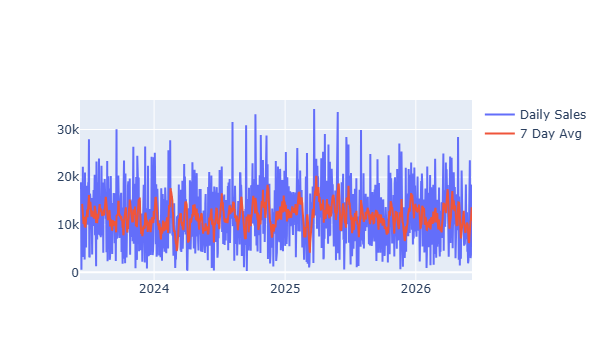

In [66]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=daily_sales["Order Date"],
        y=daily_sales["Sales"],
        name="Daily Sales"
    )
)

fig.add_trace(
    go.Scatter(
        x=daily_sales["Order Date"],
        y=daily_sales["Moving_Avg"],
        name="7 Day Avg"
    )
)

fig.show()

In [67]:
mean_sales = daily_sales["Sales"].mean()

std_sales = daily_sales["Sales"].std()

threshold = mean_sales + (2 * std_sales)

daily_sales["Anomaly"] = (
    daily_sales["Sales"] > threshold
)

In [68]:
daily_sales["Anomaly"].value_counts()

Anomaly
False    1050
True       36
Name: count, dtype: int64

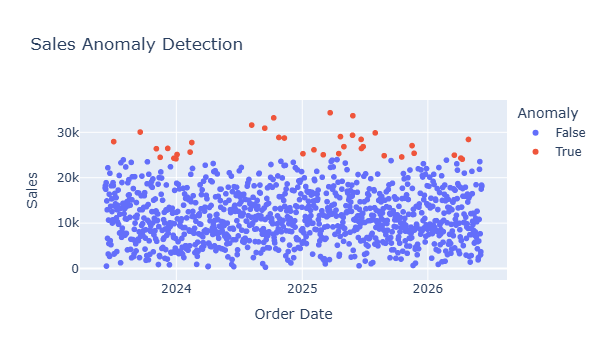

In [69]:
fig = px.scatter(
    daily_sales,
    x="Order Date",
    y="Sales",
    color="Anomaly",
    title="Sales Anomaly Detection"
)

fig.show()

In [70]:
top_regions = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

top_regions

Region
West     3240048.96
East     3226671.74
South    3185659.13
North    3159542.52
Name: Sales, dtype: float64

In [71]:
best_region = (
    df.groupby("Region")
    ["Sales"]
    .sum()
    .idxmax()
)

best_category = (
    df.groupby("Category")
    ["Sales"]
    .sum()
    .idxmax()
)

print("BUSINESS INSIGHTS")
print("-"*40)

print(
    f"Best Region : {best_region}"
)

print(
    f"Best Category : {best_category}"
)

print(
    "Recommendation : Increase marketing budget in the best performing region."
)

BUSINESS INSIGHTS
----------------------------------------
Best Region : West
Best Category : Technology
Recommendation : Increase marketing budget in the best performing region.
